In [1]:
%load_ext autoreload
%autoreload 2

# Load the BPMN Dataset

In [2]:
from mcp4cm.bpmn.dataloading import BPMNDataset, load_dataset_from_csv
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType


In [3]:
bpmn_dataset = load_dataset(dataset_type=DatasetType.BPMNMODELSET, path='data/bpmnmodelset')


Loading SAP SAM Dataset @ data/bpmnmodelset\sap_sam_2022/models:   0%|          | 0/103 [00:00<?, ?it/s]

Defining file path for saving dataset and loading it later on.

In [4]:
file_path = 'data/bpmnmodelset/processed/culled_models.csv'


In [5]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models

use_types = False

if use_types:
    file_path = 'data/bpmnmodelset/processed/culled_with_typed_names.csv'
    empty_name = 'unknown type: empty name'
else:
    file_path = 'data/bpmnmodelset/processed/culled_with_names.csv'
    empty_name = 'empty name'


extract_names_from_models(bpmn_dataset, use_types=use_types)


Extracting names from raw model done.


In [6]:
from mcp4cm.bpmn.data_extraction import filter_empty_models

print(bpmn_dataset)

filter_empty_models(bpmn_dataset, 'names', inplace=True, empty_name=empty_name)

print(bpmn_dataset)

Dataset(name=sapsam_2022_bpmn2, models=30312)
Found 808 models with empty names.
Dataset(name=sapsam_2022_bpmn2, models=29504)


In [7]:
from mcp4cm.generic.language_detection import detect_dataset_languages
from mcp4cm.bpmn.data_extraction import extract_model_languages

extract_model_languages(bpmn_dataset, key='names', empty_name=empty_name)


In [8]:
language_dict = detect_dataset_languages(bpmn_dataset)

Language Distribution Across Models:
Language: hr, Count: 418
Language: en, Count: 17213
Language: de, Count: 7569
Language: pt, Count: 310
Language: nl, Count: 215
Language: fr, Count: 476
Language: sv, Count: 110
Language: sl, Count: 220
Language: es, Count: 845
Language: fi, Count: 26
Language: ro, Count: 173
Language: pl, Count: 68
Language: it, Count: 949
Language: et, Count: 252
Language: el, Count: 75
Language: hu, Count: 149
Language: id, Count: 153
Language: ja, Count: 22
Language: da, Count: 37
Language: cy, Count: 15
Language: ru, Count: 10
Language: tl, Count: 12
Language: th, Count: 1
Language: so, Count: 6
Language: ca, Count: 19
Language: no, Count: 22
Language: vi, Count: 19
Language: lv, Count: 10
Language: af, Count: 24
Language: cs, Count: 12
Language: tr, Count: 27
Language: zh-cn, Count: 8
Language: sq, Count: 13
Language: mk, Count: 3
Language: fa, Count: 3
Language: lt, Count: 5
Language: sk, Count: 7
Language: sw, Count: 1
Language: ko, Count: 7


In [9]:
from mcp4cm.generic.language_detection import filter_models_by_language
english_dataset = filter_models_by_language(bpmn_dataset, 'en', key='names', empty_name=empty_name)
language_dict = detect_dataset_languages(english_dataset)

file_path = 'data/bpmnmodelset/processed/english_models.csv'
print(len(english_dataset))
BPMNDataset.to_csv(english_dataset, file_path);


Language Distribution Across Models:
Language: en, Count: 17204
17204


In [10]:
file_path = 'data/bpmnmodelset/processed/english_models.csv'
loaded_dataset = load_dataset_from_csv('english_bpmn', fp=file_path)

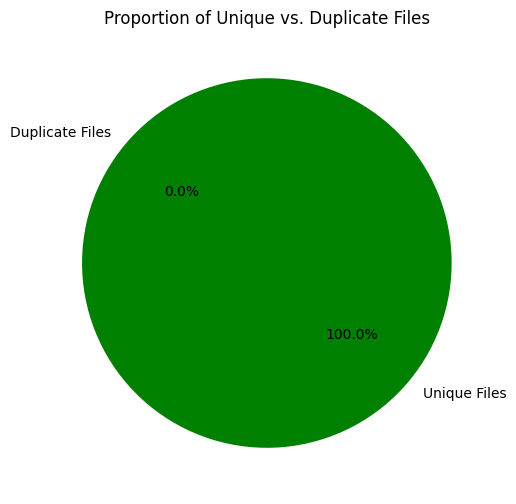

9006


In [11]:
from mcp4cm.bpmn.duplicate_detection import detect_duplicates_by_hash
detect_duplicates_by_hash(loaded_dataset, inplace=True, plt_fig=True)
print(len(loaded_dataset))


In [12]:
len(loaded_dataset)

9006

Generating Connectivity Graph
Connectivity Graph Done
Calculating connected Components
Calculating connected Components Done
Finding unique files:
Creating Duplicate Groups

=== Dataset Statistics ===
Total files processed: 9006
Total unique files: 5148
Total duplicate files: 3858
Number of duplicate groups: 0


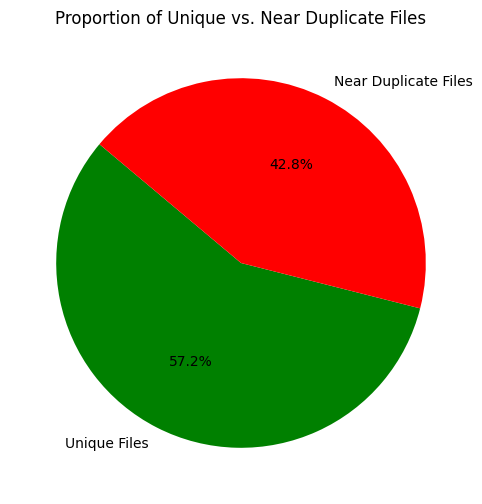

In [13]:
from mcp4cm.bpmn.duplicate_detection import tfidf_graph_near_duplicate_detector
tfidf_graph_near_duplicate_detector(loaded_dataset, threshold=0.8, inplace=True, plt_fig=True, print_results=True)

In [14]:
len(loaded_dataset)

5148